# Workshop 3: Using scqubits branch analysis

Branch analysis labels dressed states recursively rather than independently.

Very roughly, it does this:

1. find the dressed state connected to the vacuum branch
2. build the next state along a subsystem branch
3. continue recursively
4. move to the next branch

In scqubits, the main user entry point is:

`hilbertspace.generate_lookup(ordering="LX")`

In [13]:
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt

In [14]:
tmon = scq.Transmon(
    EJ=30.0,
    EC=1.2,
    ng=0.0,
    ncut=31,
    truncated_dim=3
)

res = scq.Oscillator(
    E_osc=6.0,
    truncated_dim=6
)

hilbertspace = scq.HilbertSpace([tmon, res])

g = 0.5
hilbertspace.add_interaction(
    g_strength=g,
    op1=tmon.n_operator,
    op2=res.creation_operator,
    add_hc=True # Adding the Hermitian conjugate of the interaction term. 
)

evals, evecs = hilbertspace.eigensys(evals_count=15)

## Step 1. Generate lexical-order branch labeling

In [ ]:
hilbertspace.generate_lookup(ordering="LX")
print("LX lookup generated")

LX lookup generated


## Step 2. Print dressed-state labels

The exact printing method can vary by version, so inspect the lookup object directly if needed.

In [15]:
# Try common introspection routes
print("Attributes related to lookup:")
print([x for x in dir(hilbertspace) if "lookup" in x.lower() or "index" in x.lower()])

Attributes related to lookup:
['_generate_lookup_by_overlap', '_lookup_exists', 'bare_index', 'dressed_index', 'energy_by_bare_index', 'energy_by_dressed_index', 'generate_lookup', 'get_subsys_index', 'lookup_exists', 'set_npindextuple']


In [6]:
# Depending on version, one of these may be useful:
for name in ["lookup", "_lookup"]:
    if hasattr(hilbertspace, name):
        print(f"\n{name} =")
        print(getattr(hilbertspace, name))

## Step 3. Build a simple table from the lookup

If your version exposes a mapping object, convert it into a readable table.
If not, you can still use the public lookup-related methods exposed by scqubits.

In [7]:
# This cell is intentionally exploratory because lookup internals vary slightly by version.
# Run it and adapt based on what your object contains.

lookup_obj = getattr(hilbertspace, "lookup", None)
if lookup_obj is not None:
    print(type(lookup_obj))
    print(dir(lookup_obj))

## Step 4. Visualize the low-energy dressed spectrum

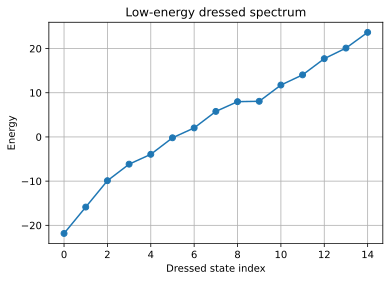

In [8]:
plt.figure(figsize=(6,4))
plt.plot(range(len(evals)), evals, marker='o')
plt.xlabel("Dressed state index")
plt.ylabel("Energy")
plt.title("Low-energy dressed spectrum")
plt.grid(True)
plt.show()

## Step 5. Compare LX with reversed subsystem order

This is where `subsys_priority` becomes important.

In [10]:
hilbertspace_rev = scq.HilbertSpace([res, tmon])

hilbertspace.add_interaction(
    g_strength=g,
    op1=tmon.n_operator,
    op2=res.creation_operator,
    add_hc=True # Adding the Hermitian conjugate of the interaction term. 
)

hilbertspace_rev.generate_lookup(ordering="LX")
print("Reversed-system LX lookup generated")

Reversed-system LX lookup generated


In [11]:
hilbertspace_rev.generate_lookup(ordering="LX", subsys_priority=[1, 0])
print("Reversed-system LX lookup with subsys_priority generated")

Reversed-system LX lookup with subsys_priority generated


Interpretation:

- without `subsys_priority`, lexical branching follows the subsystem order as stored
- with `subsys_priority=[1, 0]`, you tell scqubits which subsystem should be prioritized in branch construction

## Step 6. Try partial labeling with bare-energy ordering

In [12]:
hilbertspace.generate_lookup(ordering="BE", BEs_count=8)
print("BE lookup generated for low-energy sector")

BE lookup generated for low-energy sector


This mode is useful when you only care about a low-energy subset and do not want a full branch analysis across the whole truncated Hilbert space.

## Exercises

1. Run the same notebook with:
   - `g = 0.1`
   - `g = 0.5`
   - `g = 1.0`

   Compare how stable the branch labels appear.

2. Reverse subsystem order and compare:
   - `HilbertSpace([tmon, res])`
   - `HilbertSpace([res, tmon])`

3. Use `ordering="BE"` with different `BEs_count` values:
   - 4
   - 8
   - 12

4. Write one paragraph explaining:
   - what LX is doing conceptually
   - why DE and LX can differ
   - why `subsys_priority` matters

## Takeaway

You should now know how to:

- run branch analysis in scqubits
- compare DE and LX labeling
- deal with subsystem ordering issues
- use BE for partial low-energy labeling